In [1]:
import os
os.chdir('../')

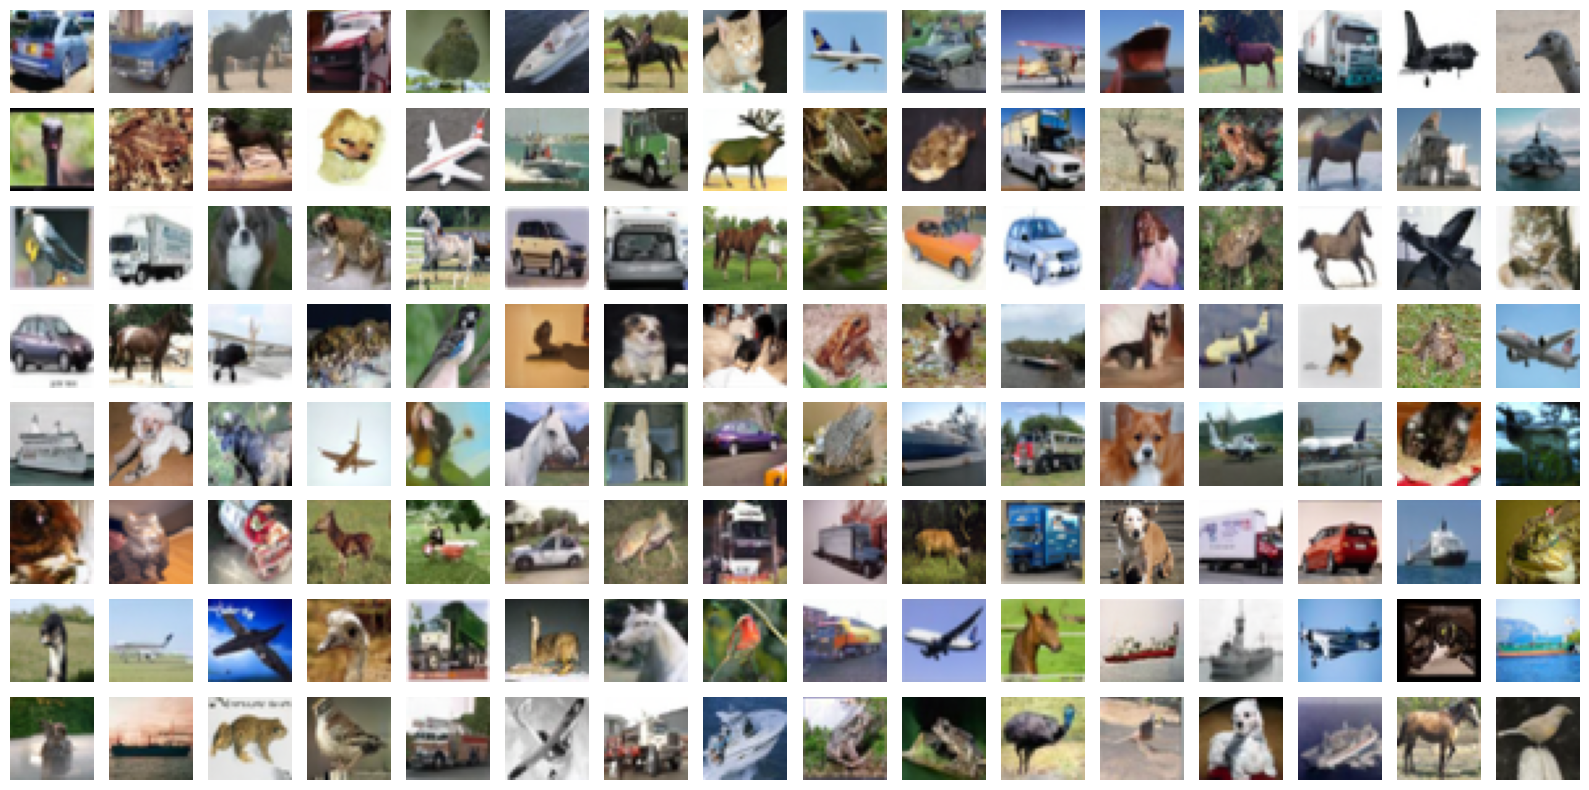

In [2]:
import math
import torch
import matplotlib.pyplot as plt

# ❶ 데이터 로드
data = torch.load('samples/edm-cifar10-32x32-uncond-vp/uni_pc_bh2_200/samples_0.pt', map_location='cpu')
imgs = data['sample_raw']          # (128, 3, 32, 32)

# ❷ [-1,1] → [0,1] 스케일 변환(이미 정규화 안 돼 있다면 생략)
imgs = (imgs.clamp(-1, 1) + 1) / 2

# ❸ (N, C, H, W) → (N, H, W, C)로 변환 후 NumPy
imgs = imgs.permute(0, 2, 3, 1).numpy()

# ❹ 그리드 파라미터
n = imgs.shape[0]          # 128
cols = 16
rows = math.ceil(n / cols) # 8

# ❺ 플롯
fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(imgs[i])
    ax.axis('off')

plt.tight_layout()
plt.show()
